# **Analisis dan Prediksi Harga Saham Indosat (ISAT) Menggunakan Multilayer Perceptron (MLP)**

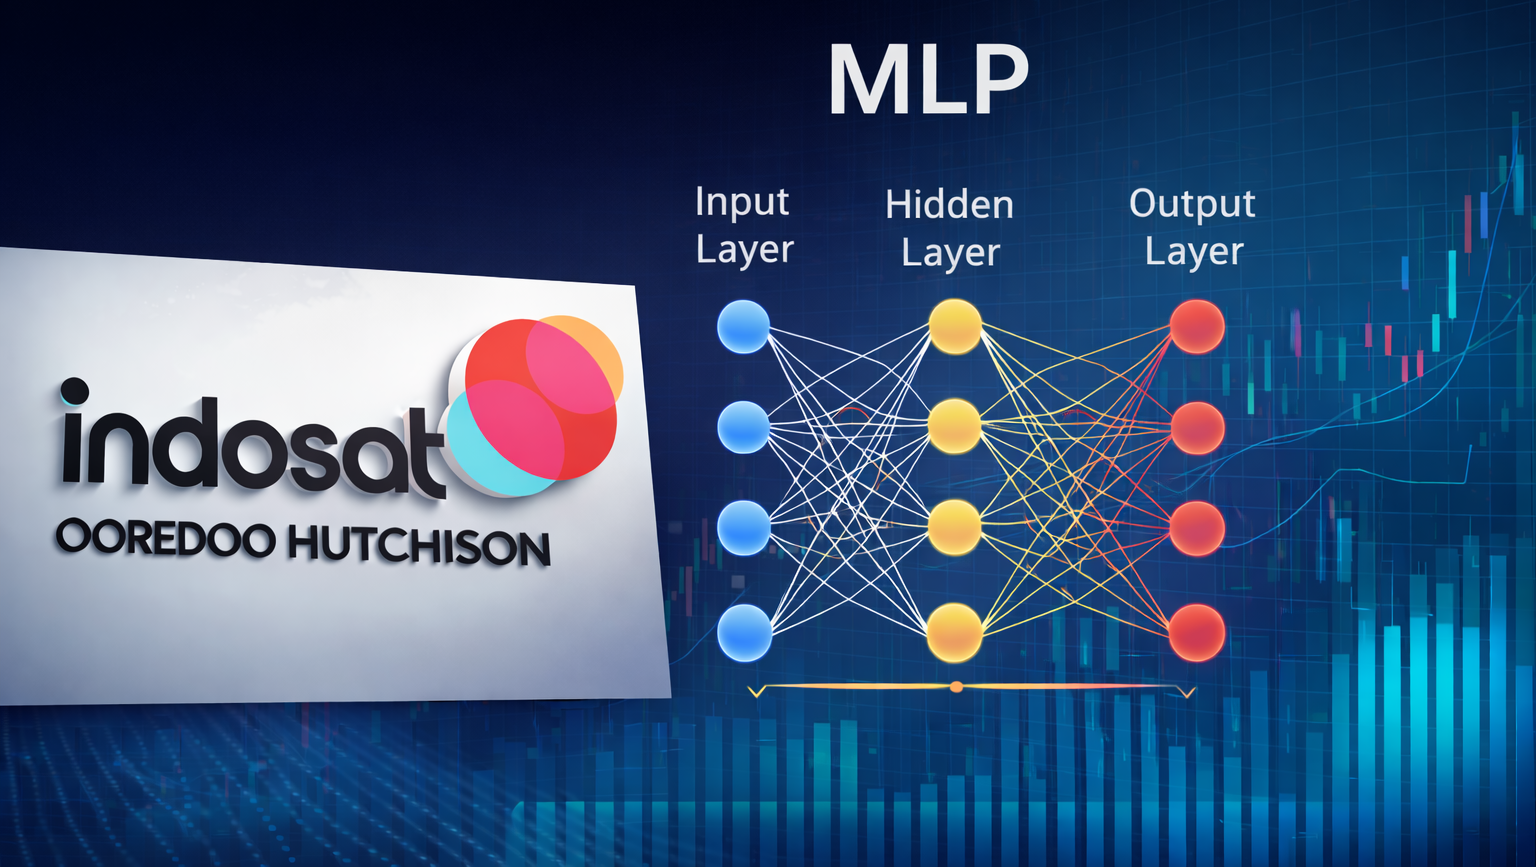

# **Business Understanding**

**Konteks**

Dalam dunia pasar modal, pemahaman yang mendalam terhadap pergerakan harga saham sangat penting bagi investor dan pelaku pasar dalam mengambil keputusan investasi yang tepat. Harga saham bersifat dinamis dan dipengaruhi oleh berbagai faktor, baik internal perusahaan maupun kondisi eksternal seperti situasi ekonomi, kebijakan pemerintah, dan sentimen pasar. Fluktuasi harga saham yang tinggi menyebabkan tingkat ketidakpastian yang besar, sehingga diperlukan analisis yang akurat untuk memprediksi pergerakan harga saham di masa mendatang.

Indosat Ooredoo Hutchison Tbk (ISAT) merupakan salah satu perusahaan telekomunikasi besar di Indonesia yang sahamnya aktif diperdagangkan di Bursa Efek Indonesia. Pergerakan harga saham ISAT menjadi perhatian penting bagi investor karena mencerminkan kinerja perusahaan dan ekspektasi pasar. Oleh karena itu, pemanfaatan metode analisis berbasis kecerdasan buatan, khususnya Jaringan Saraf Tiruan Multilayer Perceptron (MLP), menjadi relevan untuk membantu memahami pola historis harga saham dan menghasilkan prediksi yang lebih akurat sebagai dasar pengambilan keputusan investasi.

**Pernyataan Masalah (Problem Statement)**

Pergerakan harga saham Indosat Ooredoo Hutchison Tbk (ISAT) menunjukkan fluktuasi yang dipengaruhi oleh berbagai faktor, sehingga sulit diprediksi secara akurat menggunakan pendekatan konvensional. Ketidakpastian dalam pergerakan harga saham tersebut menjadi tantangan bagi investor dalam menentukan waktu yang tepat untuk melakukan keputusan investasi, baik untuk membeli, menahan, maupun menjual saham.

Dengan memanfaatkan data historis harga saham, seperti harga penutupan (terakhir/close) dan informasi waktu, diperlukan suatu pendekatan analisis yang mampu mempelajari pola dan hubungan non-linier dalam data deret waktu. Oleh karena itu, diperlukan pengembangan model prediksi berbasis machine learning yang mampu memperkirakan harga saham ISAT secara akurat pada periode mendatang. Model yang dikembangkan diharapkan dapat memberikan prediksi yang andal sebagai dasar pengambilan keputusan investasi.

Permasalahan ini menjadi penting karena prediksi harga saham yang kurang akurat dapat meningkatkan risiko kerugian bagi investor dan mengurangi efektivitas strategi investasi. Dengan adanya model prediksi yang baik, investor dapat memperoleh gambaran yang lebih jelas mengenai tren pergerakan harga saham ISAT, sehingga dapat meminimalkan risiko dan meningkatkan potensi keuntungan dalam jangka pendek maupun jangka panjang.

**Tujuan**

a. Membangun dan melatih model MLP Regressor yang mampu mempelajari pola harga saham ISAT dari data historis yang telah dinormalisasi dan disiapkan menggunakan metode sliding window.

b. Menyediakan prediksi harga saham ISAT untuk 30 hari ke depan sebagai panduan investasi jangka pendek.

c. Mengidentifikasi tren pergerakan harga saham yang paling mungkin terjadi dalam periode 30 hari tersebut (apakah naik, turun, atau sideways) untuk mendukung strategi trading yang proaktif.

# **Data Understanding**

# Persiapan Lingkungan dan Data Awal

**Mengimpor Pustaka (Library)**

Langkah awal adalah mengimpor pustaka Python yang diperlukan untuk analisis data, pemrosesan, pembangunan model MLP, dan visualisasi:

1. pandas dan numpy untuk manipulasi data.

2. matplotlib.pyplot untuk visualisasi.

3. MinMaxScaler dari sklearn.preprocessing untuk normalisasi data.

4. MLPRegressor dari sklearn.neural_network untuk model regresi MLP.

5. mean_squared_error dan mean_absolute_error dari sklearn.metrics untuk evaluasi model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

**Memuat dan Memeriksa Data (Data Loading & Inspection)**

Data harga saham Indosat (saham indosat.csv) dimuat ke dalam DataFrame df. Data ini terdiri dari 1201 baris dan 2 kolom: Tanggal dan Terakhir (harga penutupan saham).

In [ ]:
df = pd.read_csv('/content/saham indosat.csv')
df

,Tanggal,Terakhir
0,11/13/2020,2.20
1,11/16/2020,2.22
2,11/17/2020,2.23
3,11/18/2020,2.20
4,11/19/2020,2.19
...,...,...
1196,11/7/2025,2.15
1197,11/10/2025,2.07
1198,11/11/2025,2.22
1199,11/12/2025,2.16


# **Data Preparation**

**Pembersihan dan Penyiapan Data (Data Preprocessing)**

1. Konversi Tanggal: Kolom Tanggal dikonversi ke tipe data datetime dan dijadikan sebagai indeks DataFrame.

2. Pemilihan Fitur: Hanya kolom harga penutupan (Terakhir) yang digunakan untuk pemodelan deret waktu (time series).

3. Moving Average (MA): Dihitung juga MA7 (rata-rata bergerak 7 hari) dan MA30 (rata-rata bergerak 30 hari) untuk memberikan gambaran tren jangka pendek dan panjang.

4. Cek Missing Values: Hasil pemeriksaan menunjukkan tidak ada missing value pada kolom yang akan digunakan.

In [ ]:
# Konversi kolom tanggal
if 'Tanggal' in df.index.names:
    df = df.reset_index()
df.columns = df.columns.str.strip()
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='mixed')
df = df.set_index('Tanggal')

# Gunakan hanya kolom harga terakhir
data = df[['Terakhir']].copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1201 entries, 2020-11-13 to 2025-11-13
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Terakhir  1201 non-null   float64
dtypes: float64(1)
memory usage: 18.8 KB


In [ ]:
# cek banyaknya missing value
print(df.isnull().sum())

Terakhir    0
dtype: int64


# Visualisasi Data Awal

**Visualisasi Harga Saham dan Moving Average**

Visualisasi dilakukan untuk melihat tren harga saham Indosat dari waktu ke waktu, bersamaan dengan garis MA 7 Hari dan MA 30 Hari.

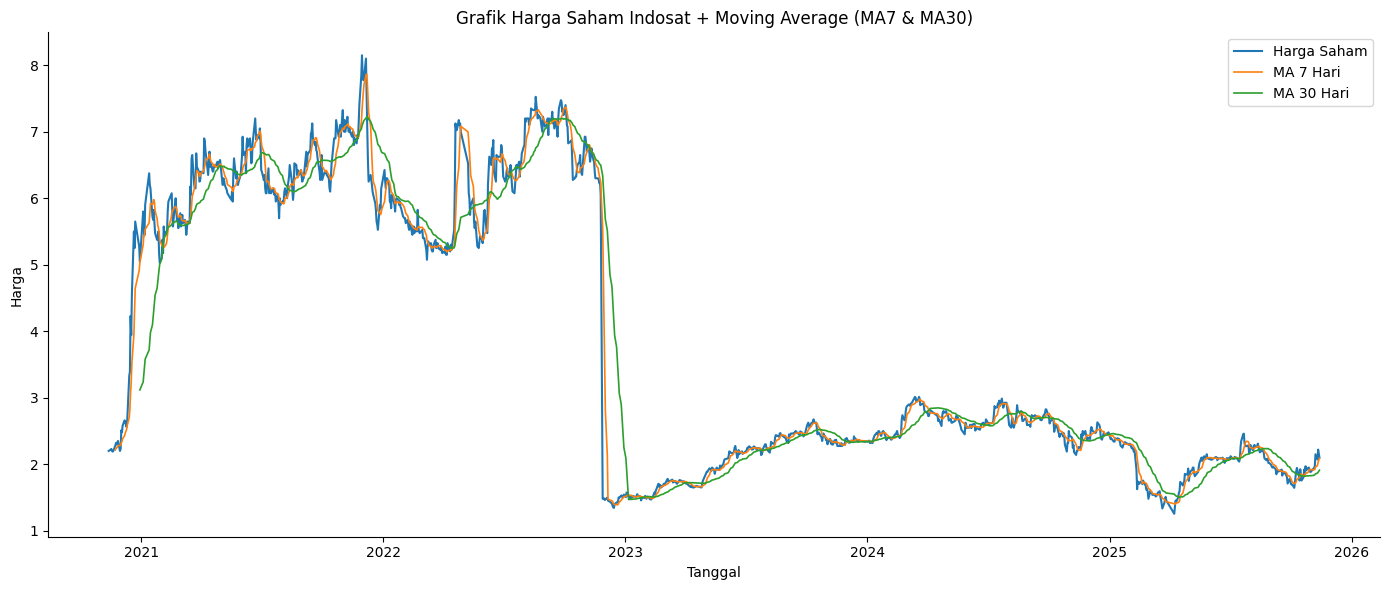

In [ ]:
df['MA7'] = df['Terakhir'].rolling(window=7).mean()     # MA jangka pendek
df['MA30'] = df['Terakhir'].rolling(window=30).mean()   # MA jangka panjang

plt.figure(figsize=(14,6))
plt.plot(df['Terakhir'], label='Harga Saham', linewidth=1.5)
plt.plot(df['MA7'], label='MA 7 Hari', linewidth=1.2)
plt.plot(df['MA30'], label='MA 30 Hari', linewidth=1.2)
plt.title('Grafik Harga Saham Indosat + Moving Average (MA7 & MA30)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()

# Hilangkan spines atas dan kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Grafik menunjukkan fluktuasi harga saham dari tahun 2020 hingga 2025. Terlihat adanya periode kenaikan dan penurunan harga yang signifikan. Garis MA membantu mengidentifikasi tren pergerakan harga.

**Normalisasi Data**

Kolom harga (Terakhir) dinormalisasi menggunakan MinMaxScaler ke rentang $[0, 1]$. Normalisasi ini penting agar MLP dapat memproses data dengan lebih efisien dan stabil.

In [ ]:
# Normalisasi Data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

**Pembentukan Sekuens Time Series (Sliding Window)**

Data deret waktu diubah menjadi format input-output (X dan y) untuk supervised learning (regresi). Teknik sliding window dengan parameter steps = 5 digunakan:

1. X (Input): Menggunakan 5 data harga sebelumnya untuk memprediksi.

2. y (Output): Harga pada langkah waktu berikutnya (ke-6).

3. Data scaled yang telah dinormalisasi digunakan dalam proses ini.

In [ ]:
# Membentuk Sekuens Time Series
def create_dataset(series, steps=5):
    X, y = [], []
    for i in range(len(series) - steps):
        X.append(series[i:i+steps, 0])
        y.append(series[i+steps, 0])
    return np.array(X), np.array(y)

steps = 5
X, y = create_dataset(scaled, steps)

# Pembagian Data

**Pembagian Data (Data Splitting)**

Data dibagi menjadi data training (80%) dan data testing (20%) berdasarkan waktu, dengan memegang prinsip time series (data terdahulu untuk training, data terbaru untuk testing).

Jumlah data training: 960

Jumlah data testing: 241

In [ ]:
# Urutkan berdasarkan tanggal (indeks)
df = df.sort_index()

# Split 80:20
split = int(len(df) * 0.8)
df_train = df.iloc[:split]
df_test  = df.iloc[split:]

print("===== DATA TRAINING =====")
print(df_train.head())
print(df_train.tail())

print("\n===== DATA TESTING =====")
print(df_test.head())
print(df_test.tail())

print("Jumlah data training:", len(df_train))
print("Jumlah data testing :", len(df_test))

===== DATA TRAINING =====
            Terakhir  MA7  MA30
Tanggal                        
2020-11-13      2.20  NaN   NaN
2020-11-16      2.22  NaN   NaN
2020-11-17      2.23  NaN   NaN
2020-11-18      2.20  NaN   NaN
2020-11-19      2.19  NaN   NaN
            Terakhir       MA7      MA30
Tanggal                                 
2024-10-30      2.32  2.351429  2.561333
2024-10-31      2.50  2.362857  2.555900
2024-11-01      2.43  2.357143  2.548133
2024-11-04      2.41  2.352857  2.537200
2024-11-05      2.39  2.365714  2.525400

===== DATA TESTING =====
            Terakhir       MA7      MA30
Tanggal                                 
2024-11-06      2.25  2.374286  2.508100
2024-11-07      2.29  2.370000  2.490267
2024-11-08      2.18  2.350000  2.468767
2024-11-11      2.14  2.298571  2.448833
2024-11-12      2.20  2.265714  2.431333
            Terakhir       MA7      MA30
Tanggal                                 
2025-11-07      2.15  1.955714  1.856500
2025-11-10      2.07  1.982

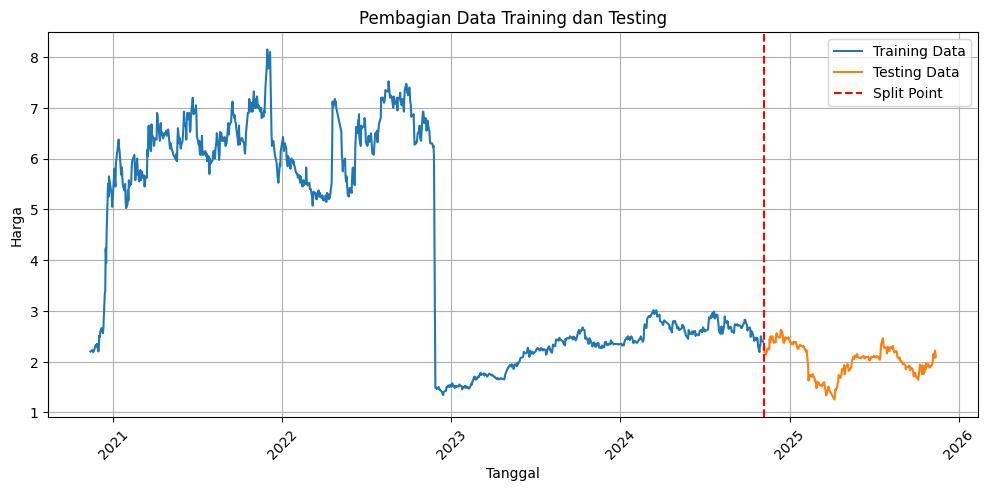

In [ ]:
# VISUALISASI SPLIT DATA
plt.figure(figsize=(12,5))
plt.plot(df_train.index, df_train['Terakhir'], label='Training Data')
plt.plot(df_test.index, df_test['Terakhir'], label='Testing Data')
plt.axvline(df.iloc[split].name, color='red', linestyle='--', label='Split Point')

plt.title('Pembagian Data Training dan Testing')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Grafik tersebut menampilkan tren harga saham Indosat (ISAT) dari akhir tahun 2020 hingga akhir tahun 2025, dibagi menjadi Data Training (garis biru) dan Data Testing (garis oranye) yang dipisahkan oleh Split Point (garis putus-putus merah). Tren harga secara keseluruhan menunjukkan volatilitas yang tinggi, dengan fase harga yang jauh lebih tinggi (berkisar antara $\text{Rp } 5.000$ hingga $\text{Rp } 8.000$) terjadi antara tahun 2021 hingga awal 2023. Setelah awal 2023, harga mengalami penurunan signifikan dan kemudian bergerak pada level yang lebih rendah dan relatif stabil (berkisar antara $\text{Rp } 1.500$ hingga $\text{Rp } 3.000$) hingga akhir periode data. Titik pemisahan data (split point) terjadi pada akhir tahun 2024, di mana data training berakhir, dan data testing dimulai, mencakup fluktuasi harga yang lebih kecil di awal tahun 2025. Pembagian ini bertujuan untuk melatih model pada data historis yang panjang dan menguji kinerjanya pada periode waktu yang lebih baru.

# **Modeling**

# Model MLP

**Pembangunan dan Pelatihan Model MLP**

Model MLPRegressor diinisialisasi dengan arsitektur:

1. Hidden Layers: Dua hidden layers, masing-masing dengan 64 neuron ((64, 64)).

2. Activation Function: relu (Rectified Linear Unit).

3. Solver: adam (Adaptive Moment Estimation).

4. Max Iterations: 500

6. Random State: 42 (untuk reproduksibilitas).

Model dilatih (fit) menggunakan data training (X_train dan y_train) yang telah disiapkan.

In [ ]:
# Split disesuaikan dengan mengurangi steps agar pembagian X dan y tetap sesuai setelah sliding window.
train_split_idx = split - steps
X_train, X_test = X[:train_split_idx], X[train_split_idx:]
y_train, y_test = y[:train_split_idx], y[train_split_idx:]

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500, random_state=42)

# **Evaluasi Model**

**Prediksi dan Perhitungan Metrik Evaluasi**

Model MLP yang telah dilatih digunakan untuk membuat prediksi pada data testing (X_test). Hasil prediksi dan data aktual di inverse scale kembali ke nilai harga saham aslinya untuk evaluasi.

In [ ]:
y_pred_test = mlp.predict(X_test)

# Invers skala agar kembali ke nilai asli
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_real = scaler.inverse_transform(y_pred_test.reshape(-1, 1))

# Hitung error
mse = mean_squared_error(y_test_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real))

print("===== EVALUASI MODEL MLP =====")
print(f"MSE   : {mse}")
print(f"RMSE  : {rmse}")
print(f"MAE   : {mae}")
print(f"MAPE  : {mape}")

===== EVALUASI MODEL MLP =====
MSE   : 0.005281858421993757
RMSE  : 0.07267639521876244
MAE   : 0.05135868944165199
MAPE  : 0.02634054326939292


Model dievaluasi menggunakan metrik umum dalam regresi:

1. Mean Squared Error (MSE): Mengukur rata-rata kuadrat kesalahan.

   Hasil: $0.0053$

2. Root Mean Squared Error (RMSE): Akar kuadrat dari MSE. Semakin rendah, semakin baik.

   Hasil: $0.0727$

3. Mean Absolute Error (MAE): Mengukur rata-rata absolut kesalahan.

   Hasil: $0.0514$

4. Mean Absolute Percentage Error (MAPE): Mengukur rata-rata persentase kesalahan absolut. Semakin rendah, semakin baik.

   Hasil: $0.0263$ (atau 2.63%)

Kesimpulan Evaluasi: Nilai MAPE 2.63% menunjukkan bahwa rata-rata kesalahan prediksi model relatif kecil, mengindikasikan bahwa model MLP memiliki akurasi yang cukup baik karena kesalahan berada di bawah 10% dalam memprediksi harga saham ISAT berdasarkan data testing.


**Visualisasi Hasil Prediksi pada Data Testing**

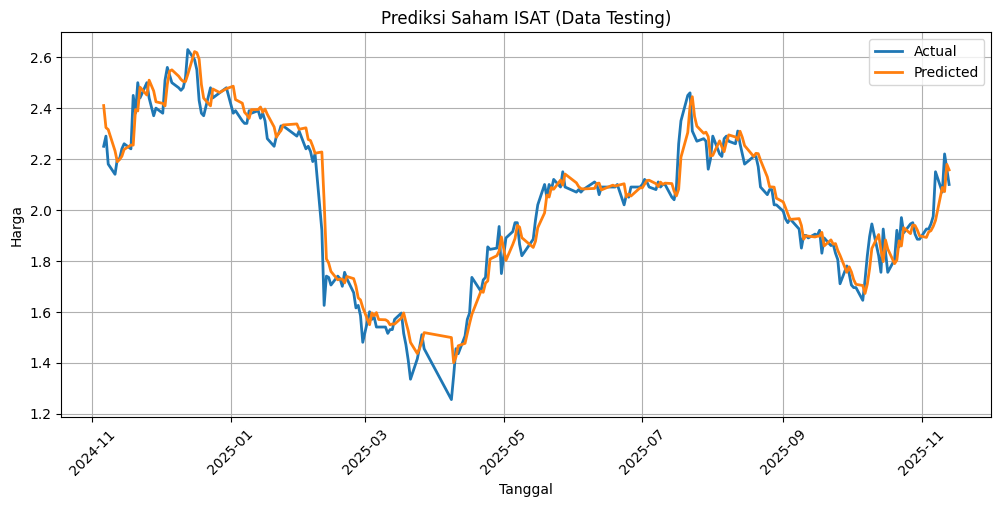

In [ ]:
# Visualisasi perbandingan nilai prediksi dengan nilai sesungguhnya (actual) pada data testing
dates = df.index
test_dates = dates[steps + len(X_train) : steps + len(X_train) + len(X_test)]

plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test_real, label='Actual', linewidth=2)
plt.plot(test_dates, y_pred_real, label='Predicted', linewidth=2)
plt.title('Prediksi Saham ISAT (Data Testing)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Grafik menunjukkan perbandingan antara harga saham Indosat (ISAT) aktual dan hasil prediksi model MLP pada data testing. Garis prediksi (orange) umumnya mengikuti pola pergerakan garis aktual (biru), baik saat terjadi penurunan tajam maupun kenaikan harga. Hal ini menunjukkan bahwa model mampu menangkap tren dan fluktuasi harga saham secara akurat. Model memiliki performa prediksi yang baik dan stabil pada data yang belum pernah dilihat sebelumnya.

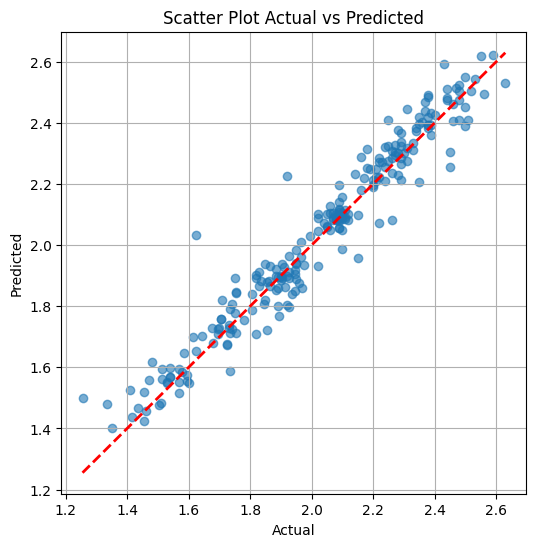

In [ ]:
# Visualisasi dengan Scatter Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--', linewidth=2)

plt.title('Scatter Plot Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()

Scatter plot menunjukkan hubungan antara nilai aktual dan nilai prediksi harga saham Indosat (ISAT) oleh model MLP. Sebagian besar titik-titik data berkumpul di sekitar garis diagonal $y=x$ (garis putus-putus merah), menunjukkan bahwa hasil prediksi sangat dekat dengan nilai aktual. Semakin rapat titik-titik mendekati garis tersebut, semakin tinggi akurasi model. Plot ini menegaskan bahwa model MLP mampu memberikan prediksi yang konsisten dan mendekati nilai aktual

# **Prediksi Harga Saham ISAT 30 Hari ke Depan**

**Prediksi 30 Hari ke Depan**

Model MLP digunakan untuk memprediksi harga saham ISAT selama 30 hari ke depan secara iteratif.

a. Jendela data terakhir (steps=5) digunakan sebagai input pertama.

b. Hasil prediksi ditambahkan ke jendela, dan data terlama dibuang (sliding window), untuk memprediksi hari berikutnya.

c. Hasil prediksi di inverse scale kembali ke nilai harga saham aslinya.

In [ ]:
last_window = scaled[-steps:].reshape(1, -1)
preds_scaled = []

current = last_window.copy()
for _ in range(30):
    pred = mlp.predict(current)[0]
    preds_scaled.append(pred)
    new_seq = np.append(current[0][1:], pred)
    current = new_seq.reshape(1, -1)

preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1))

future_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1),
                             periods=30, freq='D')

pred_df = pd.DataFrame(preds, index=future_index, columns=['Prediksi'])

# **Visualisasi Hasil Prediksi Harga Saham ISAT 30 Hari ke Depan**

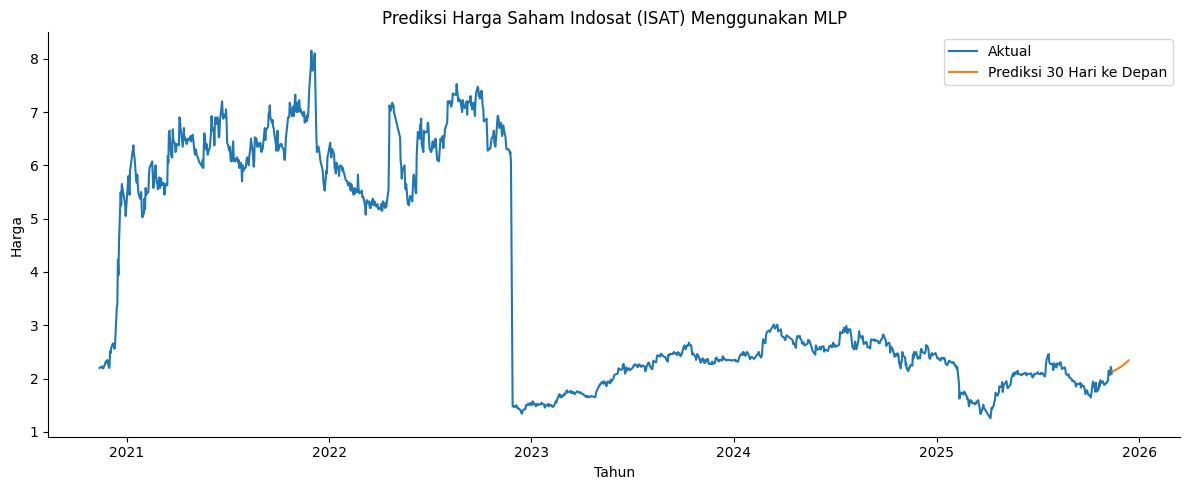


===== 30 Hari Prediksi Awal =====
            Prediksi
2025-11-14     2.137
2025-11-15     2.133
2025-11-16     2.144
2025-11-17     2.151
2025-11-18     2.153
2025-11-19     2.160
2025-11-20     2.165
2025-11-21     2.170
2025-11-22     2.176
2025-11-23     2.182
2025-11-24     2.189
2025-11-25     2.195
2025-11-26     2.201
2025-11-27     2.208
2025-11-28     2.215
2025-11-29     2.222
2025-11-30     2.229
2025-12-01     2.237
2025-12-02     2.244
2025-12-03     2.252
2025-12-04     2.260
2025-12-05     2.268
2025-12-06     2.276
2025-12-07     2.285
2025-12-08     2.294
2025-12-09     2.303
2025-12-10     2.312
2025-12-11     2.322
2025-12-12     2.332
2025-12-13     2.342


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['Terakhir'], label='Aktual')
plt.plot(pred_df['Prediksi'], label='Prediksi 30 Hari ke Depan')
plt.title('Prediksi Harga Saham Indosat (ISAT) Menggunakan MLP')
plt.xlabel('Tahun')
plt.ylabel('Harga')
plt.legend()

# Bersihkan spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n===== 30 Hari Prediksi Awal =====")
print(pred_df.head(30).round(3))

Grafik menunjukkan tren harga aktual dari 2020 hingga November 2025 (garis biru), diikuti oleh garis prediksi 30 hari ke depan (garis orange). Prediksi menunjukkan tren kenaikan harga yang stabil dalam 30 hari ke depan dari tanggal terakhir data (2025-11-13).

**Zoom Area Prediksi (30 Hari)**

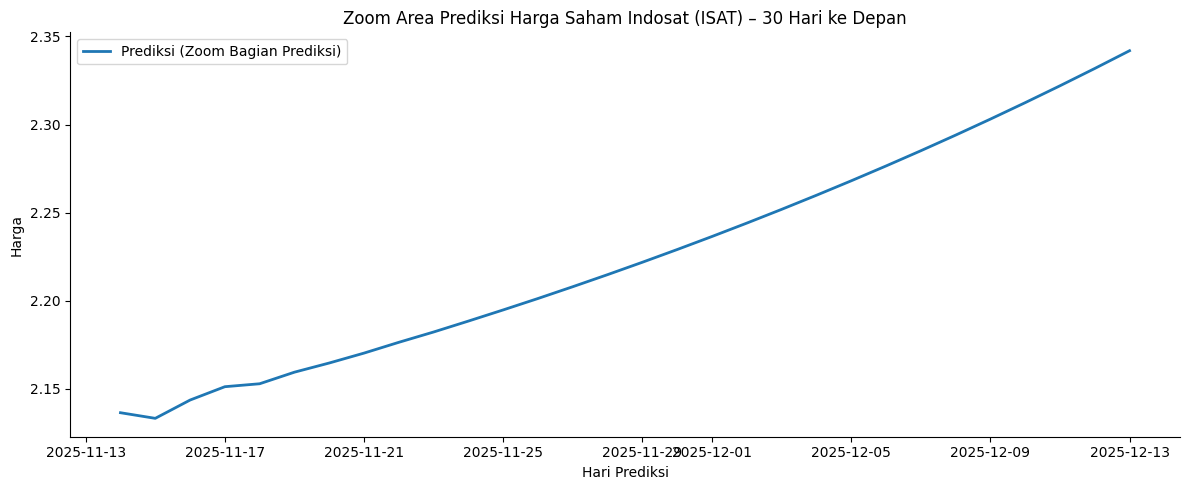


===== 30 Hari Prediksi (Zoom) =====
            Prediksi
2025-11-14     2.137
2025-11-15     2.133
2025-11-16     2.144
2025-11-17     2.151
2025-11-18     2.153
2025-11-19     2.160
2025-11-20     2.165
2025-11-21     2.170
2025-11-22     2.176
2025-11-23     2.182
2025-11-24     2.189
2025-11-25     2.195
2025-11-26     2.201
2025-11-27     2.208
2025-11-28     2.215
2025-11-29     2.222
2025-11-30     2.229
2025-12-01     2.237
2025-12-02     2.244
2025-12-03     2.252
2025-12-04     2.260
2025-12-05     2.268
2025-12-06     2.276
2025-12-07     2.285
2025-12-08     2.294
2025-12-09     2.303
2025-12-10     2.312
2025-12-11     2.322
2025-12-12     2.332
2025-12-13     2.342


In [ ]:
plt.figure(figsize=(12, 5))

# --- Hanya menampilkan bagian prediksi ---
plt.plot(pred_df['Prediksi'], label='Prediksi (Zoom Bagian Prediksi)', linewidth=2)

plt.title('Zoom Area Prediksi Harga Saham Indosat (ISAT) – 30 Hari ke Depan')
plt.xlabel('Hari Prediksi')
plt.ylabel('Harga')
plt.legend()

# Bersihkan spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\n===== 30 Hari Prediksi (Zoom) =====")
print(pred_df.head(30).round(3))

Grafik menunjukkan hasil zoom area prediksi harga saham Indosat (ISAT) selama 30 hari ke depan. Berdasarkan grafik, terlihat bahwa harga saham ISAT pada awal periode prediksi mengalami fluktuasi kecil, kemudian menunjukkan tren meningkat secara bertahap dan konsisten hingga akhir periode prediksi  dari $\text{Rp } 2.137$ (2025-11-14) menjadi $\text{Rp } 2.342$ (2025-12-13).

# **Kesimpulan Proyek Analisis dan Prediksi Harga Saham ISAT**

Penelitian ini berhasil membangun model prediksi harga saham Indosat (ISAT) menggunakan Multilayer Perceptron (MLP) Regressor berdasarkan data deret waktu tahun 2020 hingga 2025. Proses persiapan data dilakukan secara menyeluruh, termasuk normalisasi dan penerapan metode sliding window (5 langkah waktu), yang sangat penting untuk menangkap pola volatilitas historis harga saham ISAT.

Hasil evaluasi menunjukkan bahwa kinerja model terbukti sangat baik pada data testing (20% data), dengan nilai Mean Absolute Percentage Error (MAPE) sebesar 2.63%. Metrik lain (MSE: 0.0053, RMSE: 0.0727, MAE: 0.0514) juga mengonfirmasi kemampuan model dalam mereplikasi dan memprediksi pergerakan harga saham dengan tingkat error yang rendah.

Model MLP yang telah divalidasi kemudian digunakan untuk memprediksi harga 30 hari ke depan secara iteratif (dimulai dari 14 November 2025). Hasil prediksi menunjukkan adanya tren kenaikan harga yang stabil dan bertahap dalam periode tersebut, dengan harga diprediksi meningkat dari Rp 2.137 menjadi Rp 2.342. Secara keseluruhan, model MLP ini efektif sebagai alat bantu keputusan investasi.  Namun, hasil prediksi ini harus tetap dipertimbangkan bersama analisis pasar yang lebih luas.